In [43]:
from met4a import *

path = "/workspaces/met4a_data/2026_02_12/1770931655.952085.met4a.pkl"
data = load_pickle(path)
data.keys()

dict_keys(['start_time', 'ref_pressure', 'scale_fac', 'nsamp', 'times', 'pressure', 'temp', 'rh'])

In [44]:
data['start_time'], data['nsamp']

(1770931655.952085, 1000)

In [45]:
from datetime import datetime

ts = data['start_time']
dt = datetime.fromtimestamp(ts)
print(dt)

2026-02-12 21:27:35.952085


## Make Time Axis

In [46]:
import pandas as pd

start_time = ts   # your epoch start time

# convert start time to datetime
start_dt = pd.to_datetime(start_time, unit="s")

# convert offsets to timedeltas
time_axis = start_dt + pd.to_timedelta(data["times"], unit="s")

In [49]:
def convert_to_datetime(start_time, offsets):
    start_dt = pd.to_datetime(start_time, unit="s")
    time_axis = start_dt + pd.to_timedelta(offsets, unit="s")
    return time_axis

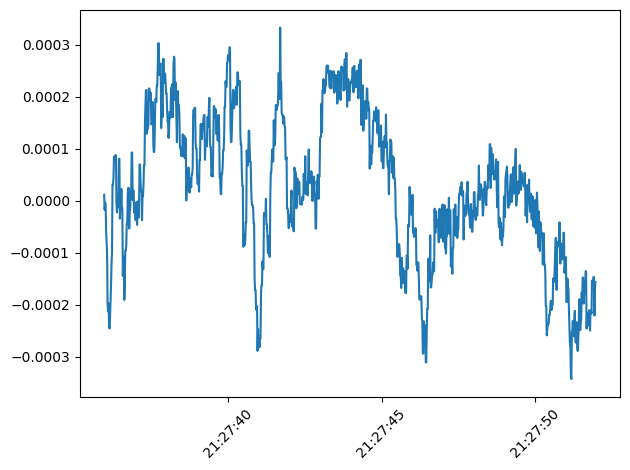

In [50]:
%matplotlib inline
from matplotlib import pyplot as plt

time_axis = convert_to_datetime(data['start_time'], data['times'])

plt.plot(time_axis, data["pressure"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Plotting Two Samples

In [84]:
path1 = "/workspaces/met4a_data/2026_02_12/1770931655.952085.met4a.pkl"
data1 = load_pickle(path1)
ts1 = data1['start_time']
max_time1 = data1['times'][-1]

path2 = "/workspaces/met4a_data/2026_02_12/1770931672.2044873.met4a.pkl"
data2 = load_pickle(path2)
ts2 = data2['start_time']
min_time2 = data2['times'][0]

In [85]:
time_diff = ts2-ts1
print(f"time difference: {time_diff} seconds")

ts2 - (ts1 + max_time1)

time difference: 16.252402305603027 seconds


np.float64(0.24851155281066895)

In [86]:
data1['times'][1] - data1['times'][0]

np.float64(0.015129566192626953)

In [90]:
end_time = datetime.fromtimestamp(data1['times'][-1] + data1['start_time'])
ts2 - (data1['times'][-1] + data1['start_time']), data2['times'][1] - data2['times'][0]

(np.float64(0.24851155281066895), np.float64(0.01640772819519043))

In [51]:
time_axis1 = convert_to_datetime(data1['start_time'], data1['times'])
time_axis2 = convert_to_datetime(data2['start_time'], data2['times'])

In [55]:
def plot_pressure(time_axis, pressure, label):
    plt.plot(time_axis, pressure, label=label)
    plt.xticks(rotation=45)

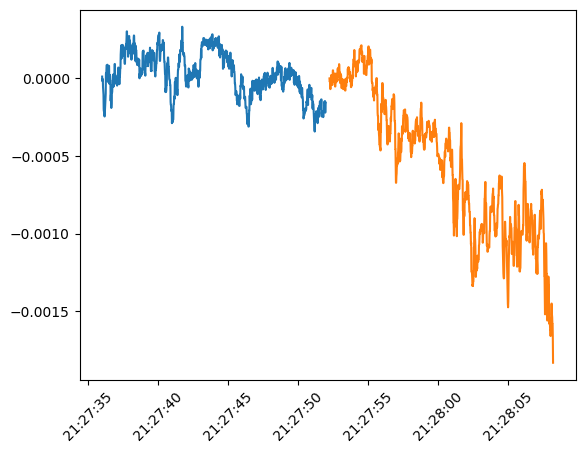

In [56]:
plot_pressure(time_axis1, data1["pressure"], label="Dataset 1")
plot_pressure(time_axis2, data2["pressure"], label="Dataset 2")

## Automating Sample Coalating

In [66]:
from met4a import *

directory_path = "/workspaces/met4a_data/2026_02_12"
data_list = load_all_pickles(directory_path)

coalesce_time = []
coalesce_pressure = []
for data in data_list:
    time_axis = convert_to_datetime(data['start_time'], data['times'])
    coalesce_time.append(time_axis)
    coalesce_pressure.append(data['pressure'])

(array([20496.89583333, 20496.90625   , 20496.91666667, 20496.92708333,
        20496.9375    , 20496.94791667, 20496.95833333, 20496.96875   ,
        20496.97916667]),
 [Text(20496.895833333332, 0, '12 21:30'),
  Text(20496.90625, 0, '12 21:45'),
  Text(20496.916666666668, 0, '12 22:00'),
  Text(20496.927083333332, 0, '12 22:15'),
  Text(20496.9375, 0, '12 22:30'),
  Text(20496.947916666668, 0, '12 22:45'),
  Text(20496.958333333332, 0, '12 23:00'),
  Text(20496.96875, 0, '12 23:15'),
  Text(20496.979166666668, 0, '12 23:30')])

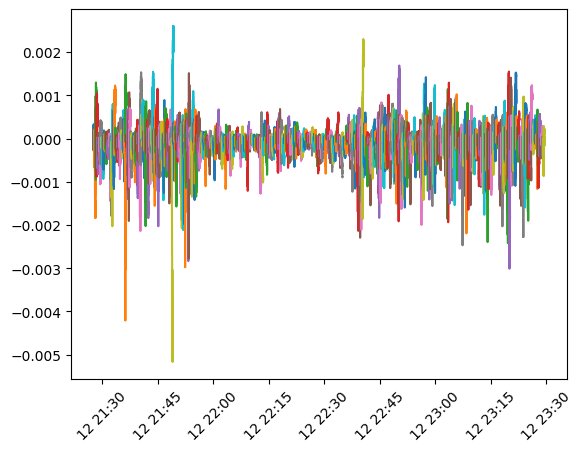

In [91]:
for idx in range(len(coalesce_time)):
    plt.plot(coalesce_time[idx], coalesce_pressure[idx], label=f"Dataset {idx+1}")
plt.xticks(rotation=45)